In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import ROOT
import seaborn as sns

%jsroot off

In [2]:
output_dir = "/lustre/r3b/ywang/test/s122/test_aug18"
filename = "hit.test0.root"
rootfile = ROOT.TFile(f"{output_dir}/{filename}", "read")
tree_reader = ROOT.TTreeReader("evt", rootfile)
# tree_reader.GetTree().Print()

In [3]:
tree_reader.Restart()
neuland_hits = ROOT.TTreeReaderArray(ROOT.R3B.Neuland.Hit)(tree_reader, "NeulandHits")
event_header = ROOT.TTreeReaderValue(ROOT.R3BEventHeader)(tree_reader, "EventHeader.")

In [52]:
def go_to_next(min_hits = 10):
    while tree_reader.Next():
        # print(f"size: {mille_data.GetSize()}")
        if neuland_hits.GetSize() < min_hits:
            continue
        # for bar_data in mille_data:
        #     print(f"module_num: {bar_data.module_num}, meas: {bar_data.tsync_meas}")
        break

In [44]:
def show_hits(neuland_hits):
    for hit in neuland_hits:
        print(f"module_id: {hit.module_id}")

In [48]:
plot_height = 8
n_bars = 50
bar_length = 250
bar_width_z = 5
bar_width_xy = 5
n_planes = 26

def plot_neuland(is_yz: bool, axis):
    axis.set_xlim(0, n_planes*bar_width_z)
    axis.set_ylim(-bar_length / 2, bar_length / 2)
    axis.set_xlabel("z (cm)")
    if is_yz:
        axis.set_ylabel("y (cm)")
    else:
        axis.set_ylabel("x (cm)")
    axis.plot([0, n_planes * bar_width_z], [bar_length / 2, bar_length / 2], color = "black")
    add_factor = 0 if is_yz else 1;
    for plane_id in range(26):
        plane_left_pos = plane_id * bar_width_z
        axis.plot([plane_left_pos, plane_left_pos], [-bar_length/2, bar_length/2], color="black")
        if ((plane_id + add_factor) % 2) == 0:
            for bar_id in range(n_bars):
                bar_x1 = plane_left_pos
                bar_y1 = (bar_id - n_bars / 2) * bar_width_xy
                bar_x2 = plane_left_pos + bar_width_z
                bar_y2 = bar_y1
                axis.plot([bar_x1, bar_x2], [bar_y1, bar_y2], color = "black")

def add_module_ids(axes, hits):
    for hit in hits:
        module_id = hit.module_id
        plane_id = ROOT.R3B.Neuland.Common.ModuleID2PlaneID(module_id)
        z_pos = ROOT.R3B.Neuland.Common.PlaneID2ZPos(plane_id)
        disp = ROOT.R3B.Neuland.Common.GetBarVerticalDisplacement(module_id + 1)
        c = patches.Rectangle(xy=(z_pos - bar_width_z/2., disp - bar_width_xy/2), height=bar_width_xy, width=bar_width_z, color='r')
        is_horizontal = ROOT.R3B.Neuland.Common.IsPlaneIDHorizontal(plane_id)
        if is_horizontal:
            axes[0].add_patch(c)
        else:
            axes[1].add_patch(c)



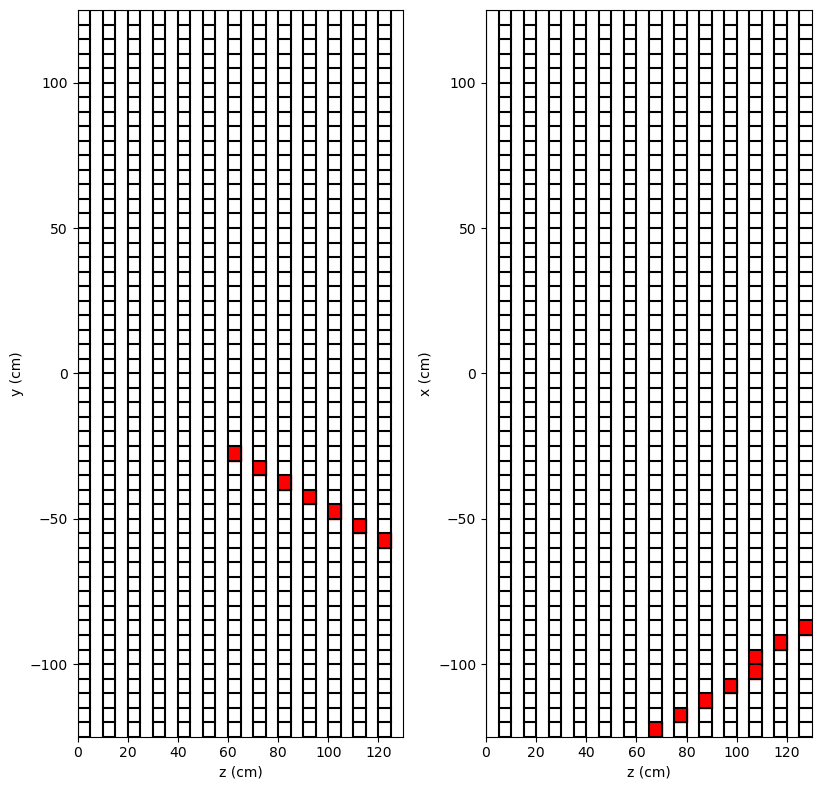

In [55]:
figure, axes = plt.subplots(nrows=1, ncols=2, figsize=(plot_height/bar_length*n_planes*bar_width_z*2, plot_height))

go_to_next(15)

plot_neuland(True, axes[0])
plot_neuland(False, axes[1])
add_module_ids(axes, neuland_hits)
figure.tight_layout()